In [5]:
import numpy as np
import scipy.linalg as la
import scipy.integrate as sint
import sympy as sp
from sympy.functions.special.bsplines import bspline_basis
from sympy import chebyshevt, chebyshevu, sqrt, pi, symbols
from sympy import legendre
import matplotlib.pyplot as plt
import itertools
from scipy.interpolate import interp1d

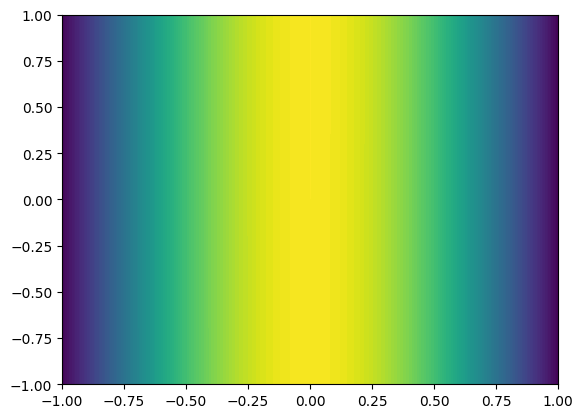

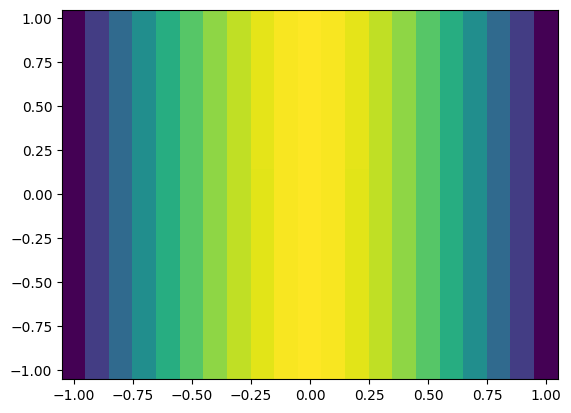

In [6]:
# Parameters
N = 20    # Number of Chebyshev collocation points in space and velocity
dt = 0.01     # Time step size
Nt = int(1 / dt) # Number of time step
epsilon = 0.1
nu = 1.0
R = 8 # Rank
z_first = -1
z_end = 1

# Chebyshev points on interval [-1,1] 
def chebyshev_points(N):
    return np.cos(np.pi * np.arange(N) / (N - 1))

# Spatial and velocity collocation points
x_p = chebyshev_points(N)  
z_q = (z_first + z_end)/2 + (z_end - z_first)/2 * chebyshev_points(N)  

# Maxwellian M
# def Maxwellian(rho_x, T_x, x_p, z_q):
#     d_v = 1  # Dimensionality of velocity space
#     return rho_x(x_p) / (2 * np.pi * T_x(x_p)**(d_v / 2)) * np.exp(-z_q**2 / 2)
def Maxwellian(rho_x, T_x, x_p, z_q):
    d_v = 1
    rho_vals = rho_x(x_p)[:, None]                  # shape (N, 1)
    T_vals = T_x(x_p)[:, None]                      # shape (N, 1)
    z_vals = z_q[None, :]                           # shape (1, N)
    return rho_vals / (2 * np.pi * T_vals**(d_v / 2)) * np.exp(-z_vals**2 / 2)

# Spatial basis functions 
x = sp.symbols('x')
z = sp.symbols('z')
s = sp.symbols('s')

def phi(n, x):
    Tn = chebyshevt(n, x)
    if n == 0: #orthonormalization
        return Tn / np.sqrt(np.pi)
    else:
        return Tn * np.sqrt(2/np.pi)

phis = []
for n in range(N):
    phis.append(lambda x, n=n: phi(n, x))

# print(phis[0](2))
# print(phis[1](2))
# print(phis[7](2))
# Derivative of spatial basis functions
def dphi(n, x):
    if n == 0:
        return 0
    else:
        Un_1 = chebyshevu(n-1, x)  
        dTn = n * Un_1
        return dTn * np.sqrt(2/np.pi)

dphis = []
for n in range(N):
    dphis.append(lambda x, n=n: dphi(n, x))


# Velocity basis functions 
def psi(n, z):
    Tn = chebyshevt(n, z)
    if n == 0: #orthonormalization
        return Tn / np.sqrt(np.pi)
    else:
        return Tn * np.sqrt(2/np.pi)

psis = []
for n in range(N):
    psis.append(lambda z, n=n: psi(n, z) )

# Derivative of velocity basis functions
def dpsi(n, z):
    if n == 0:
        return 0  
    else:
        Un_1 = chebyshevu(n-1, z)  
        dTn = n * Un_1
        return dTn * np.sqrt(2/np.pi)

dpsis = []
for n in range(N):
    dpsis.append(lambda z, n=n: dpsi(n, z))

# Compute velocity variables v = z sqrt(T) + u
# def v(T_x, u_x, x_p, z_q):
#     return z_q * np.sqrt(T_x(x_p)) + u_x(x_p)
def v(T_x, u_x, x_p, z_q):
    sqrt_T = np.sqrt(T_x(x_p))[:, None]    # shape (N, 1)
    u_val = u_x(x_p)[:, None]              # shape (N, 1)
    z = z_q[None, :]                       # shape (1, N)
    return z * sqrt_T + u_val              # shape (N, N)
                                         

# Evaluate \phi_i(x_p) at Chebyshev collocation points
A = np.array([[phi(i, x_p[p]) for p in range(N)] for i in range(N)], dtype=float)  # Shape: (N, N)

# Evaluate derivative of phi_i againt x at Chebyshev collocation points
A_der = np.array([[dphi(i, x_p[p]) for p in range(N)] for i in range(N)], dtype=float)  # Shape: (N, N)

# Evaluate \psi_j(z_q) at Chebyshev collocation points
B = np.array([[psi(j, z_q[q]) for q in range(N)] for j in range(N)], dtype=float) # Shape: (N, N)

# Evaluate derivative of \psi_j againt x at Chebyshev collocation points
B_der = np.array([[dpsi(j, z_q[q]) for q in range(N)] for j in range(N)], dtype=float)  # Shape: (N, N)

# Evaluate \int \psi_j(z)dz 
int_psi_z = np.array([sint.quad(psis[j],z_first,z_end)[0] for j in range(N)])  

# Evaluate \int z\psi_j(z)dz
zpsis = []
for n in range(N):
    zpsis.append(lambda z, n=n: z * psi(n, z))
int_zpsi_z = np.array([sint.quad(zpsis[j],z_first,z_end)[0] for j in range(N)]) 

# Evaluate \int z^2\psi_j(z)dz 
# Evaluate \int z\psi_j(z)dz
z2psis = []
for n in range(N):
    z2psis.append(lambda z, n=n: z**2 * psi(n, z))

int_z2psi_z = np.array([sint.quad(z2psis[j],z_first,z_end)[0] for j in range(N)]) 
#int_z2psi_z = np.array([sp.integrate(z**2 * psi(j,z),(z,z_first,z_end)).evalf() for j in range(R)]) 

# Evaluate \int z^3\psi_j(z)dz 
# Evaluate \int z\psi_j(z)dz
z3psis = []
for n in range(N):
    z3psis.append(lambda z, n=n: z**3 * psi(n, z)) 
    
int_z3psi_z = np.array([sint.quad(z3psis[j],z_first,z_end)[0] for j in range(N)]) 
#int_z3psi_z = np.array([sp.integrate(z**3 * psi(j,z),(z,z_first,z_end)).evalf() for j in range(R)]) 



# # Initial f
# f_ini_x = lambda x: (1 + .01 * np.cos(x/2)) / (np.sqrt(2 * np.pi))
# f_ini_z = lambda v: np.exp(-v**2 / 2)
# Initial f
def f_ini_x(x):
    return 1+.00001*x
#f_ini_x = 1/ (sp.sqrt(2 * sp.pi))
#f_ini_x = (1 + .01 * sp.cos(x/2)) / (sp.sqrt(2 * sp.pi))
#f_ini_s = sp.exp(-s**2 / 2) 
def f_ini_s(s):
    return np.exp(-s**2/2)

xp = np.linspace(-1, 1, 21)
vp = np.linspace(z_first, z_end, 21)
fp = np.outer(f_ini_x(xp),f_ini_s(vp))
X, Y = np.meshgrid(xp, vp)
plt.contourf(X,Y,fp,100)
#plt.pcolor(X, Y, fp)
plt.show()


#rho_x = f_ini_x * sp.integrate(f_ini_s, (s,z_first,z_end))
#rho_x = lambda x : f_ini_x(x) * sint.quad(f_ini_s,z_first,z_end)
idfs,_ = sint.quad(f_ini_s,z_first,z_end)
#print(idfs)
def rho_x(x):
    return f_ini_x(x) * idfs
#print("rho_x(.2)",rho_x)
#u_x = (f_ini_x / rho_x) * sp.integrate(s * f_ini_s, (s,z_first,z_end)) 
idfs2,_ = sint.quad(lambda s: s * f_ini_s(s), z_first,z_end)

def u_x(x):
    return (f_ini_x(x) / rho_x(x)) * idfs2
# u_x = lambda x : (f_ini_x(x) / rho_x(x)) * idfs2
# print("u_x",u_x)

#print(u_x)
#T_x = (1 / rho_x) * sp.integrate((s-u_x)**2 * f_ini_s,(s,z_first,z_end))
#FIXME: assumed u_x is constant
idfs3,_ = sint.quad(lambda s : (s-u_x(0))**2 * f_ini_s(s),z_first,z_end)

def T_x(x):
    return (1 / rho_x(x)) * idfs3
# T_x = lambda x : (1 / rho_x(x)) * idfs3

#print(T_x)
f_ini_xz = lambda x,z : f_ini_x(x)*f_ini_s(np.sqrt(T_x(x))*z + u_x(x))
#print("f_ini_xz(2,2),",f_ini_xz(2.,2.),f_ini_x(2.)*f_ini_s(np.sqrt(T_x(2))*2.+u_x(2)))
f_ini_xz_vals = np.array([f_ini_xz(x,z) for x,z in itertools.product(x_p,z_q)])

#f_ini_z_vals = np.array([[float(f_ini_z.subs({x: x_p[p], z: z_q[q]}).evalf()) for q in range(N)] for p in range(N)], dtype=float)
                        
C = np.zeros((N,N))
vec_f_ini_xz_vals = f_ini_xz_vals.flatten(order='F')
# print(A.shape)
# print(B.shape)
# print(vec_f_ini_z_vals.shape)
coff = np.linalg.solve(np.kron(B.T,A.T), vec_f_ini_xz_vals)
C = coff.reshape(N,N, order='F')
#print("C",C)
def f_interpolated(x,v,u,T):
    psi_vals = np.array([f(x) for f in psis], dtype=float)
    phi_vals = np.array([f((v - u(x)) / np.sqrt(T(x))) for f in phis], dtype=float)
    return np.sum(C*np.outer(psi_vals,phi_vals))
xp = np.linspace(-1, 1, 21)
vp = np.linspace(z_first, z_end, 21)
fp2 = [f_interpolated(x,v,u_x,T_x) for x,v in itertools.product(xp,vp)]
fp2 = np.array(fp2).reshape(len(xp), len(vp)) 
X, Y = np.meshgrid(xp, vp)
plt.pcolor(X, Y, fp2.T)
plt.show()

In [7]:


# Evaluate f at collocation points f(x_p,z_q)
def eval_f(C, A, B): 
    f_val = A.T @ C @ B 
    return f_val

# Evaluate derivaive of z against x at colloction points 
# def dz_x(T_x, u_x, x_p, z_q):
#     dT_dx = sp.diff(T_x,x)
#     du_dx = sp.diff(u_x,x)
#     return np.array([[-du_dx.subs(x,x_p[p])/sp.sqrt(T_x.subs(x, x_p[p])) - (dT_dx.subs(x,x_p[p] * z_q[q]) / (2 * T_x.subs(x, x_p[p]))) for q in range(N)] for p in range(N)])

# Numeric derivative
def numeric_derivative(f, x, dx=1e-6):
    return (f(x + dx) - f(x - dx)) / (2 * dx)

def dz_x(T_x, u_x, x_p, z_q):
    N = len(x_p)
    dzx = np.zeros((N,N))
    for p in range(N):
        dT_dx = numeric_derivative(T_x, x_p[p])
        du_dx = numeric_derivative(u_x, x_p[p])
        Tx_val = T_x(x_p[p])
        for q in range(N):
            # Compute dz/dx element
            dzx[p,q] = (-du_dx / np.sqrt(Tx_val)) - (dT_dx * z_q[q]) / (2 * Tx_val)
    return dzx
    
# Evaluate derivative of f againt x at collocation points D_xf(x_p, z_q)
def eval_D_xf(C, A, B, A_der, B_der, x_p, z_q, T_x, u_x):
    Df_val = A_der.T @ C @ B + np.multiply(dz_x(T_x, u_x, x_p, z_q), A.T @ C @ B_der) 
    return Df_val

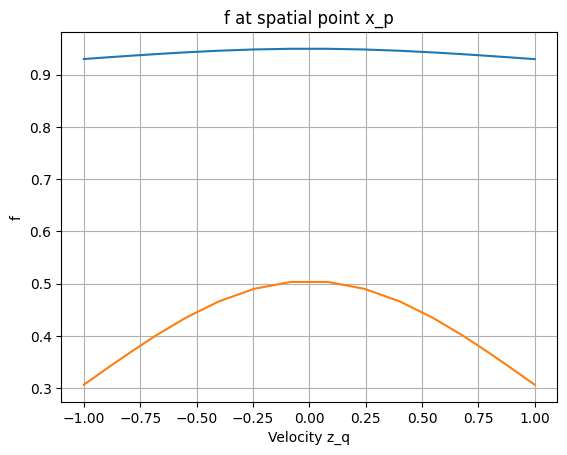

9.72099601621091


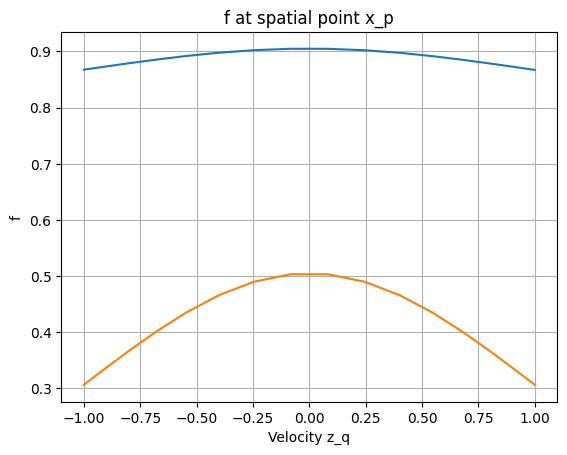

8.748849984031304


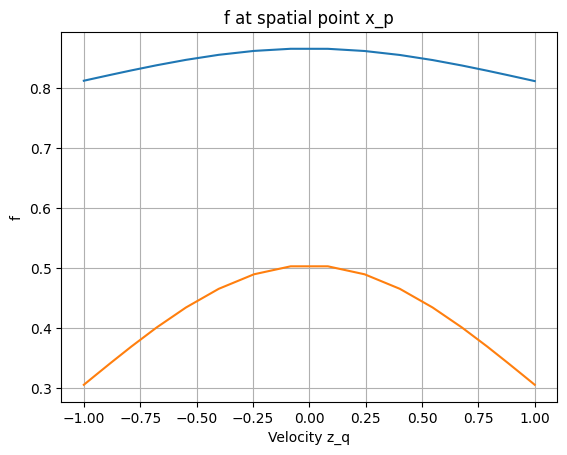

7.8738898553546335


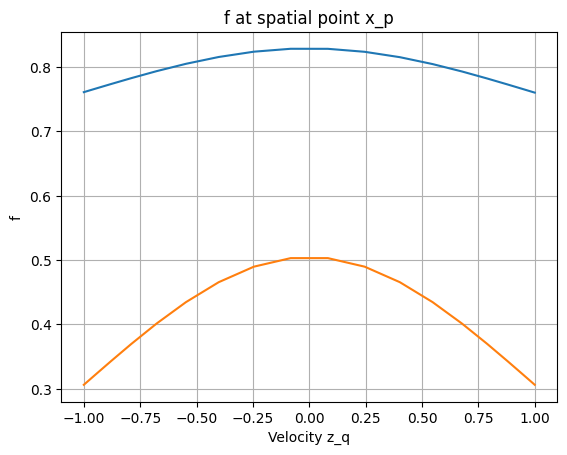

7.0864021865351905


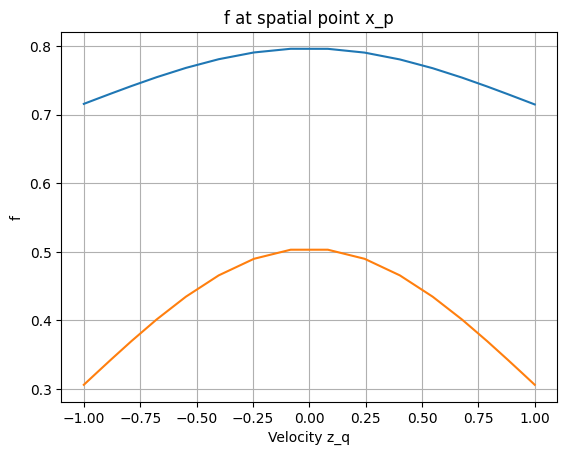

6.377644285735704


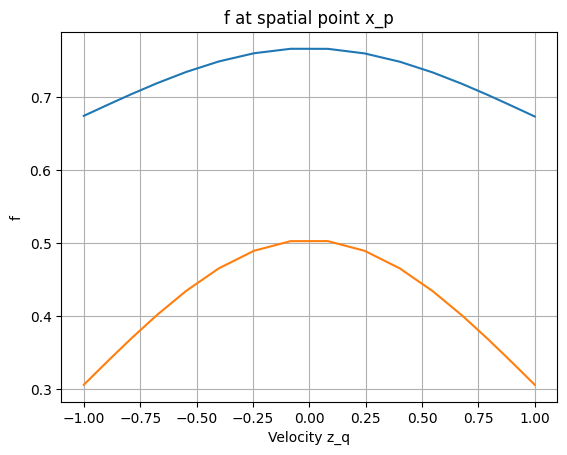

5.739747176471945


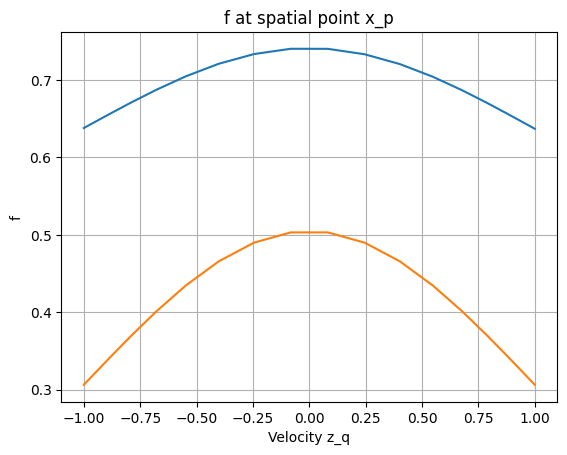

5.165628268326721


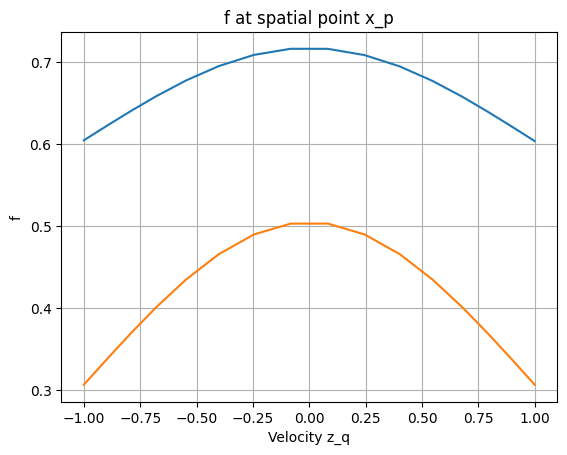

4.648912762016567


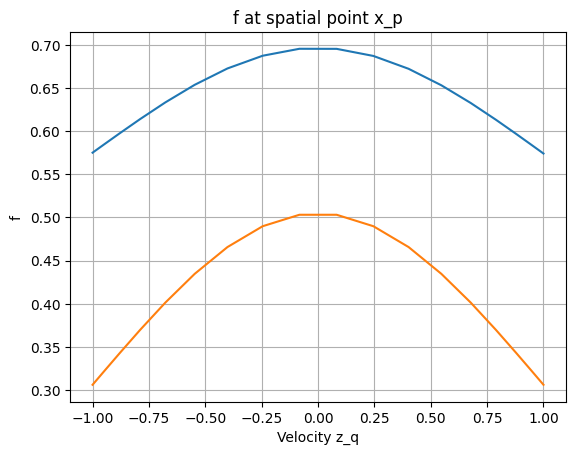

4.183862913851926


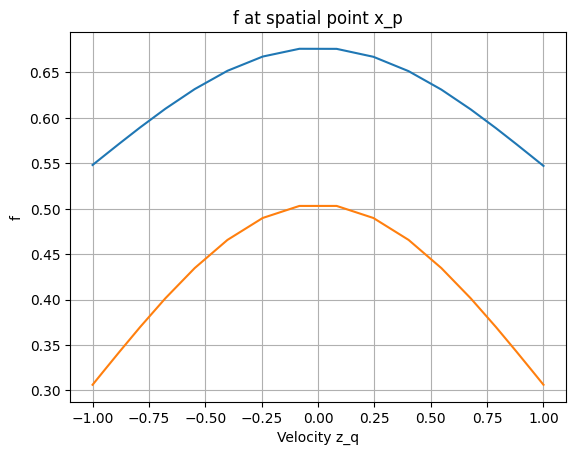

3.765314372570602


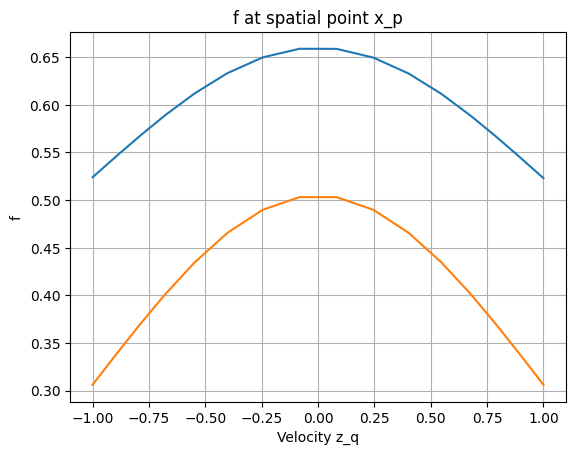

3.3886188805696964


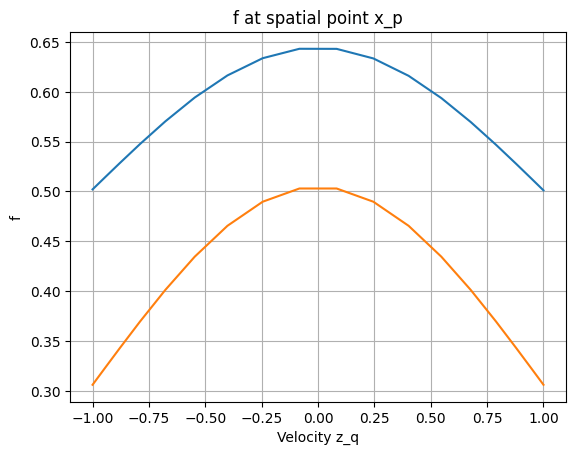

3.0495927026184098


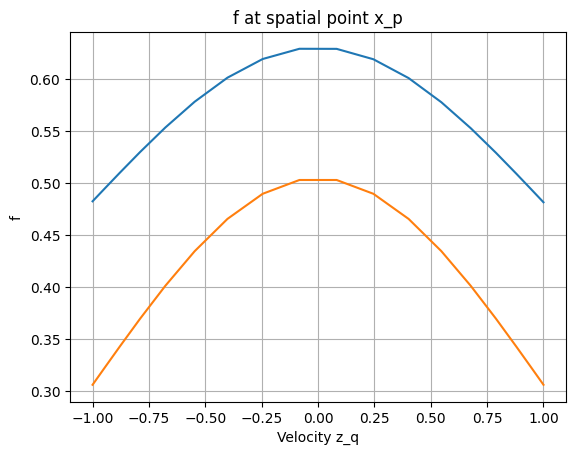

2.744470209024269


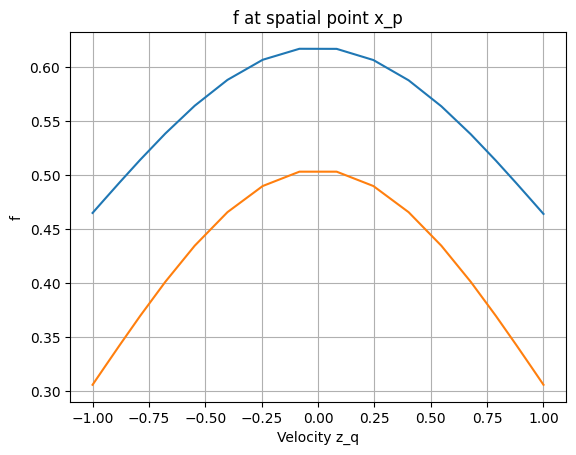

2.4698620976731305


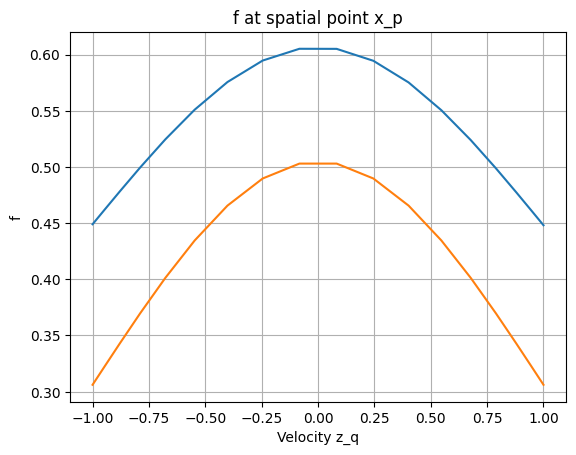

2.222717791030168


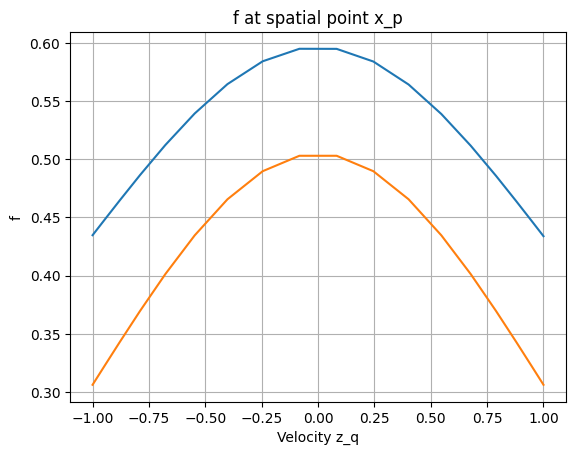

2.000291590658162


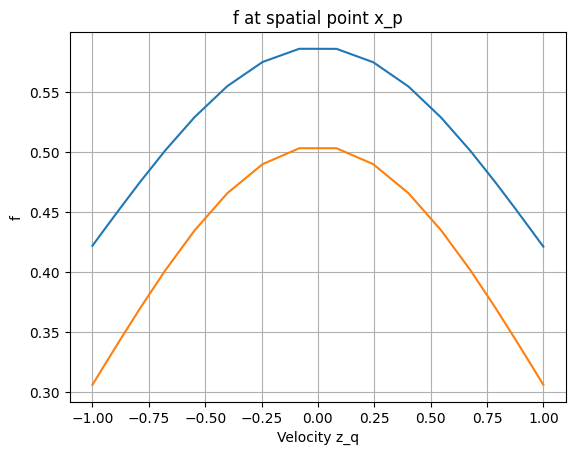

1.8001122136051662


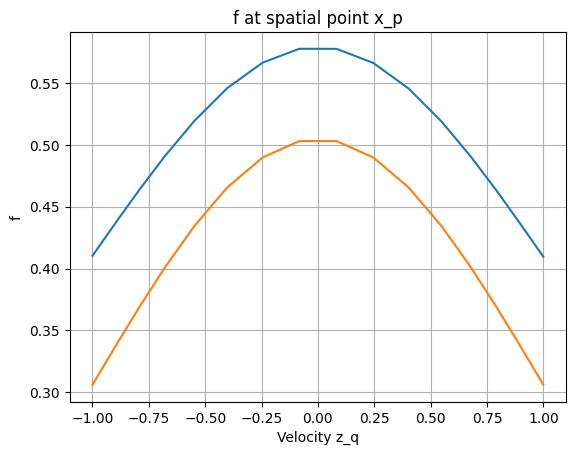

1.619955372617593


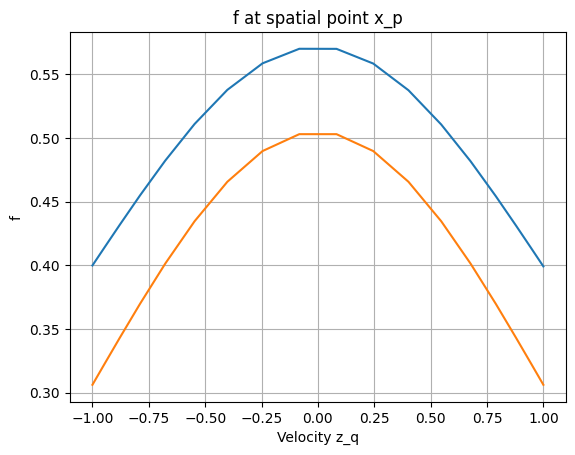

1.4578190959573334


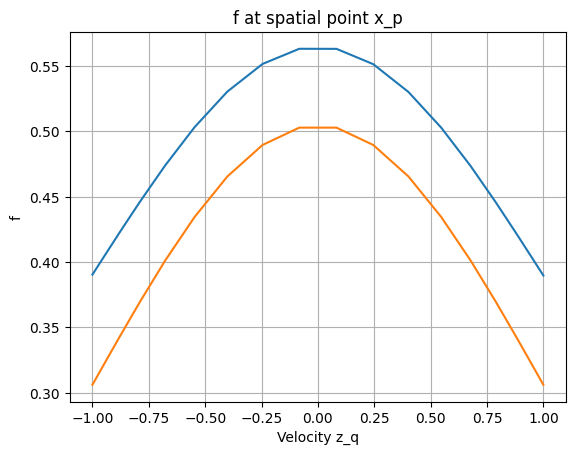

1.311901513039061


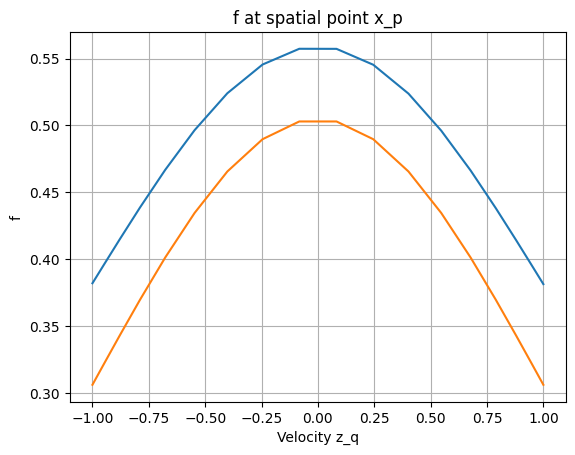

1.1805808594845402


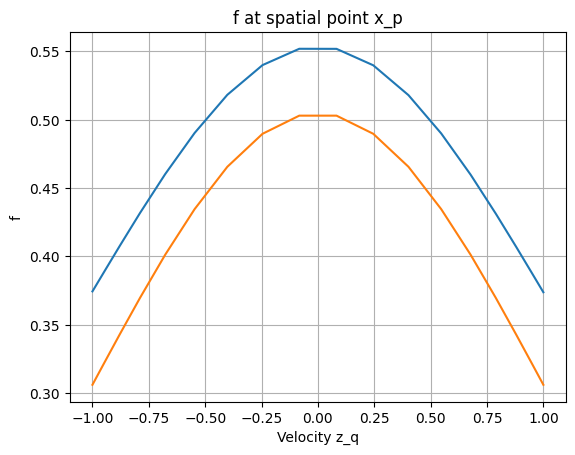

1.0623974798298537


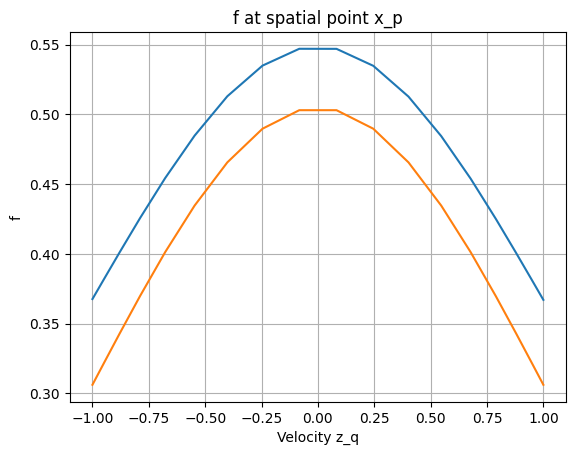

0.9560376282936712


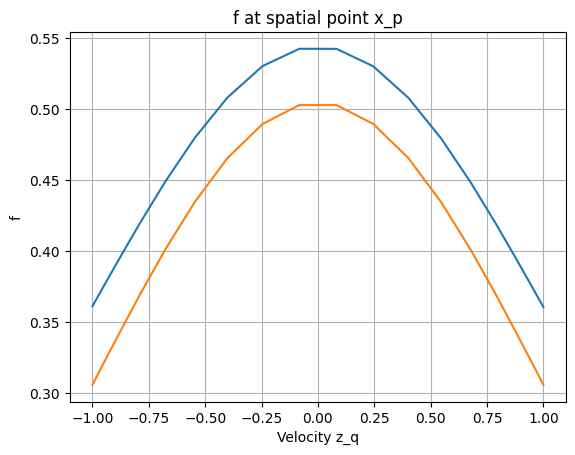

0.8603188879645491


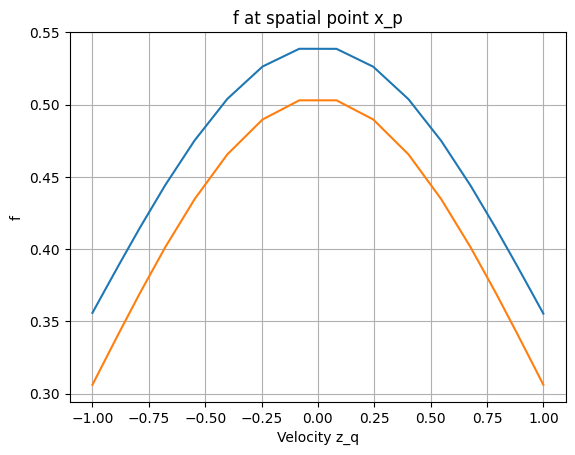

0.7741770467212432


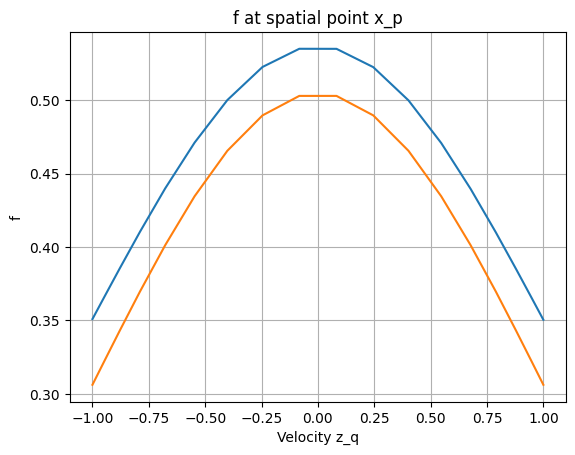

0.6966542843577609


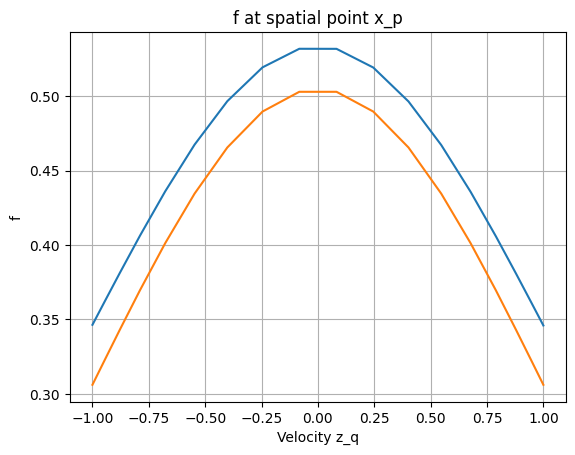

0.6268885399253507


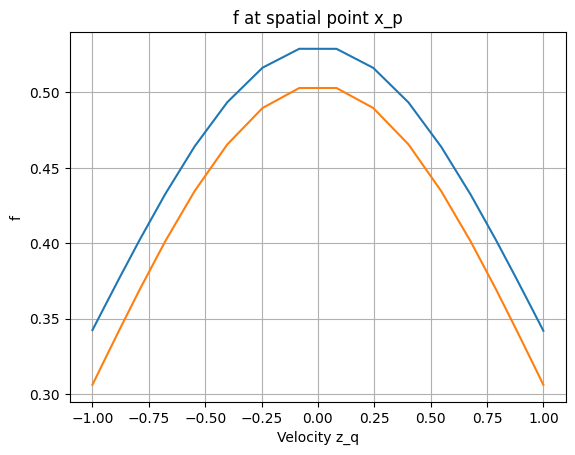

0.5641039413939918


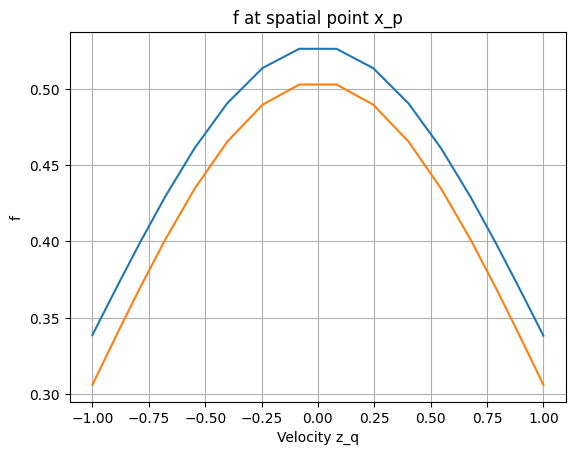

0.507602191510895


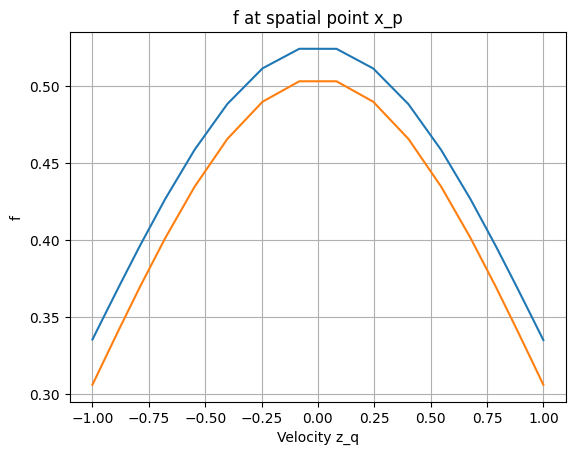

0.45675481434025994


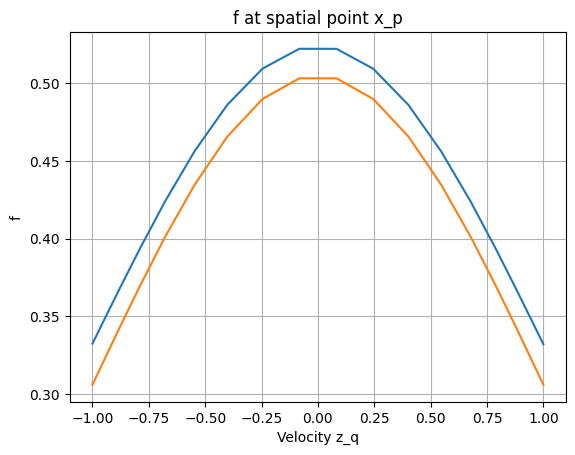

0.4109961765044874


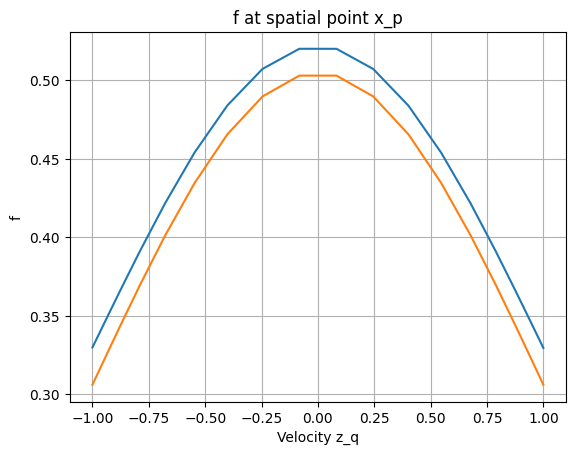

0.36981720574100063


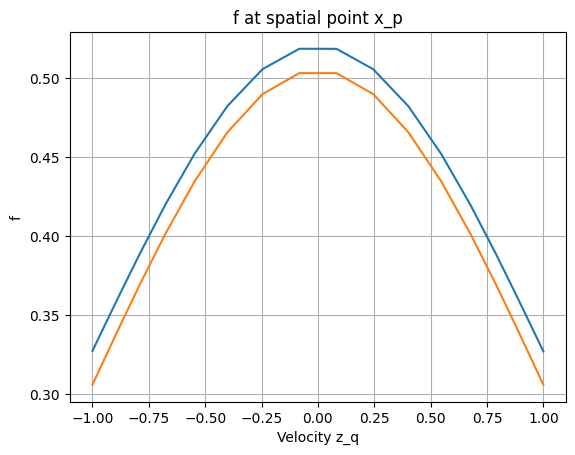

0.33275973711513734


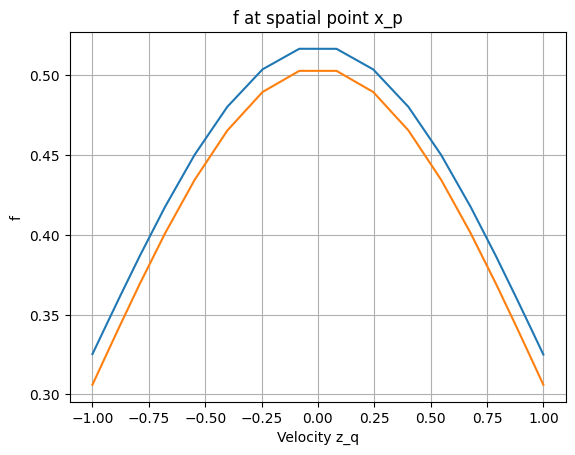

0.2994114241888032


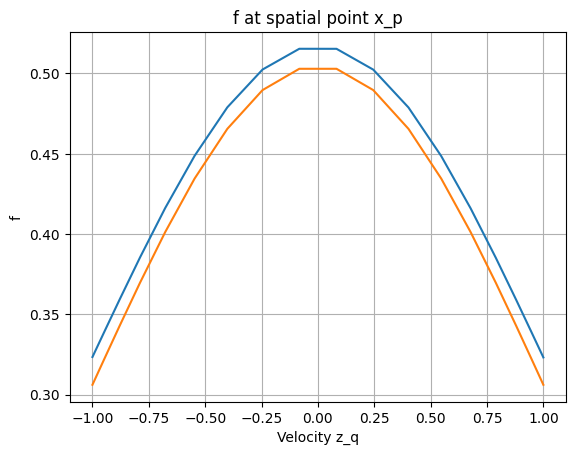

0.26940115870792125


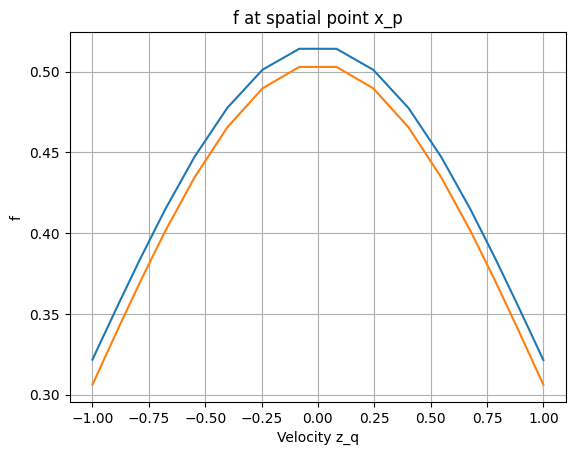

0.2423949480065981


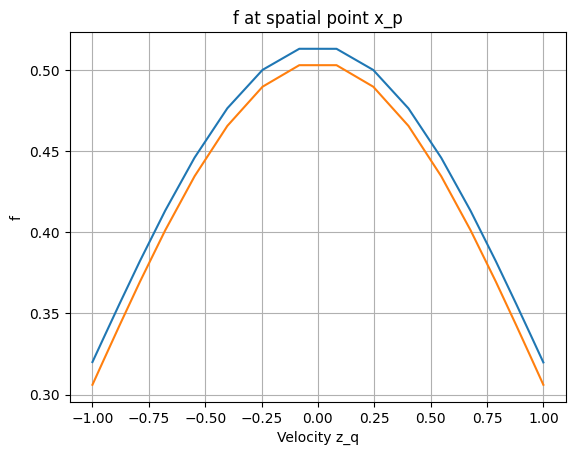

0.21809220440389912


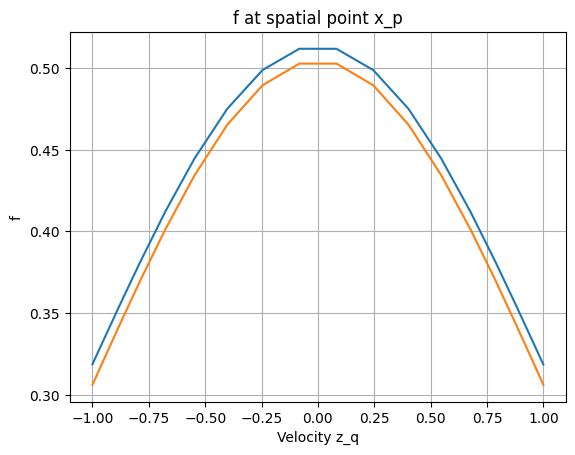

0.19622240543085806


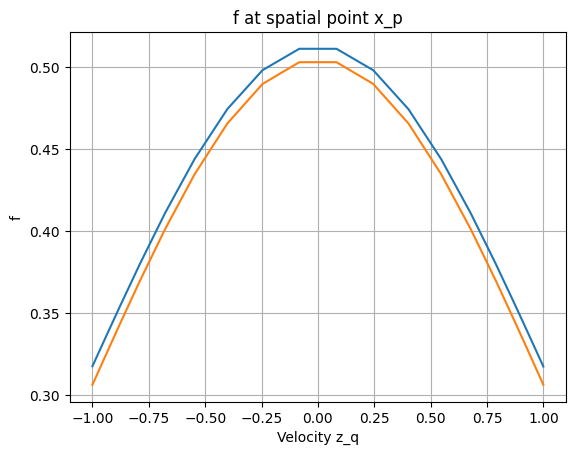

0.17654208784186073


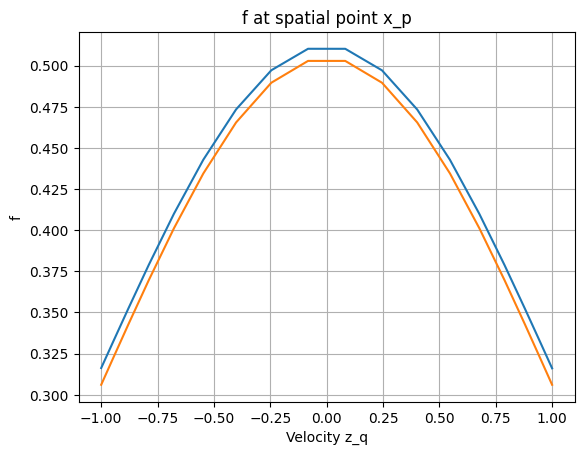

0.15883214206172777


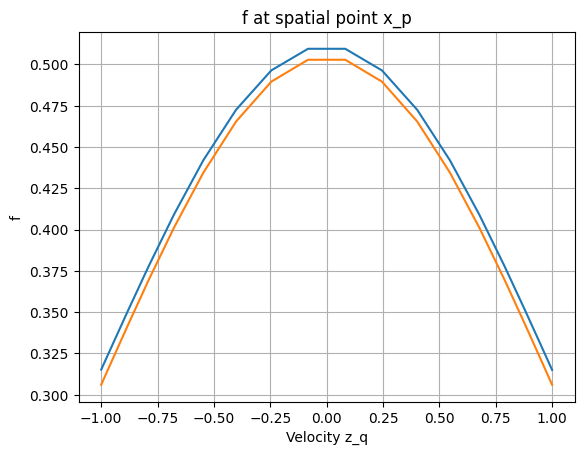

0.14289537705108826


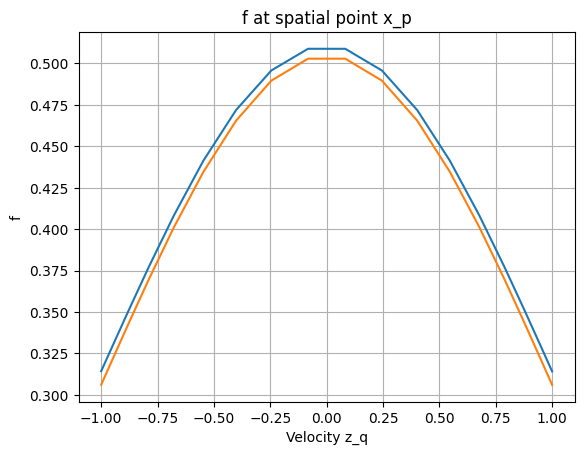

0.1285543285721778


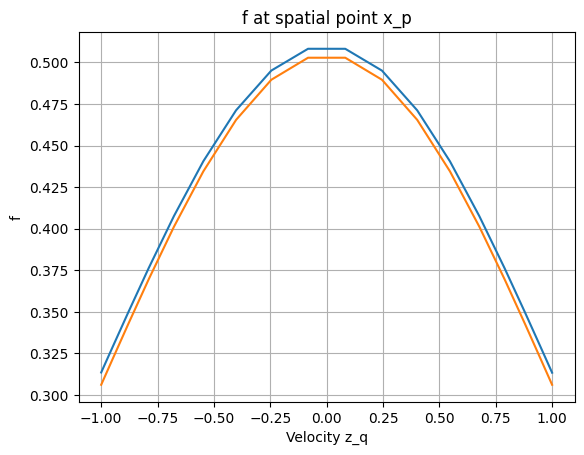

0.1156492865344946


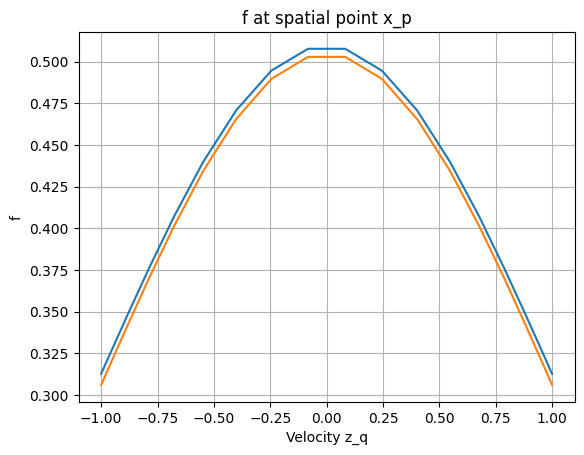

0.10403651952966773


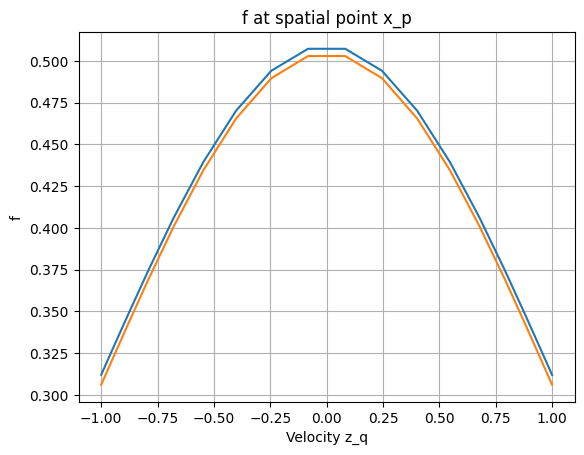

0.09358667685229574


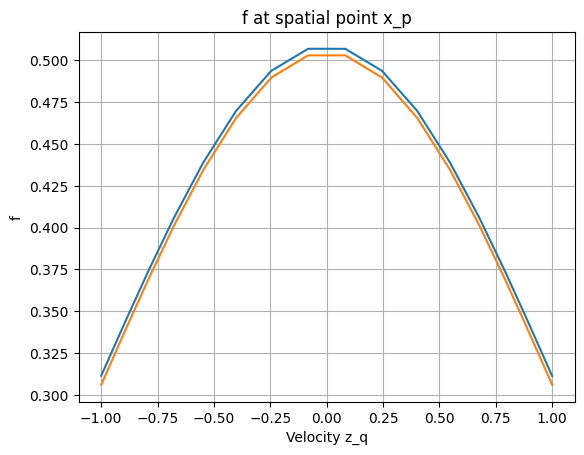

0.08418335027051425


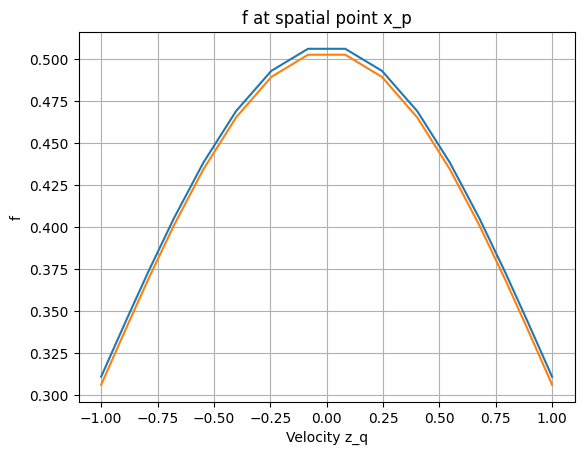

0.07572177958215875


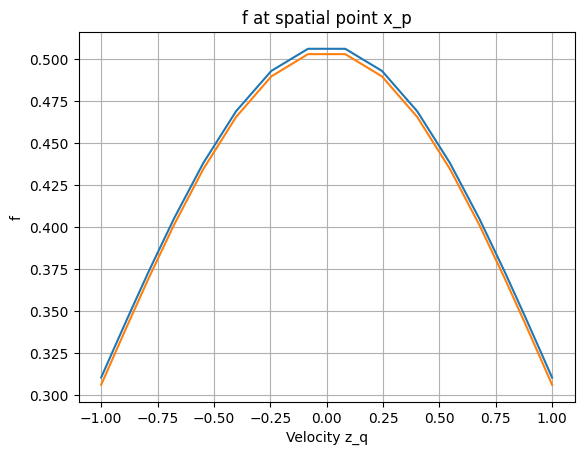

0.06810768758805688


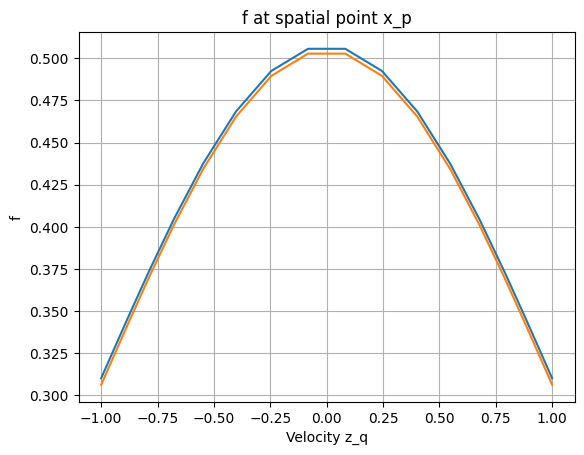

0.06125623154854398


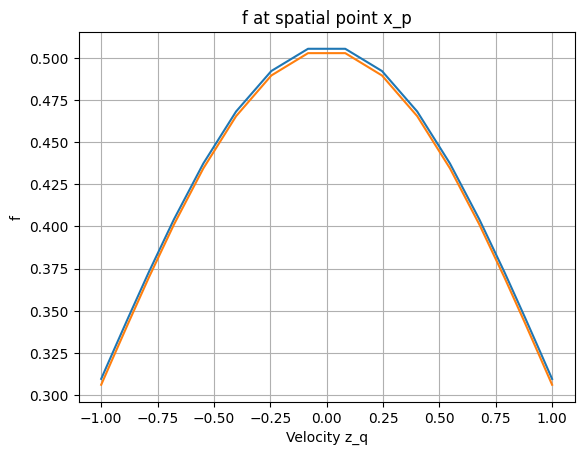

0.0550910594811004


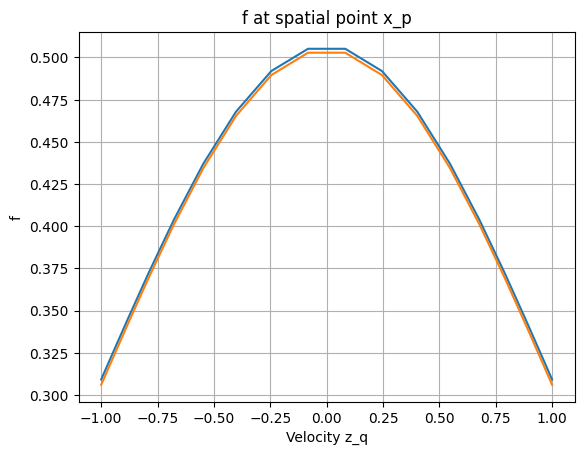

0.04954346082210751


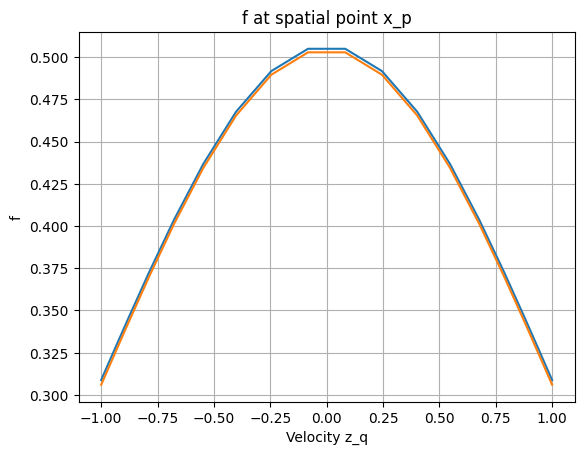

0.044551602020572144


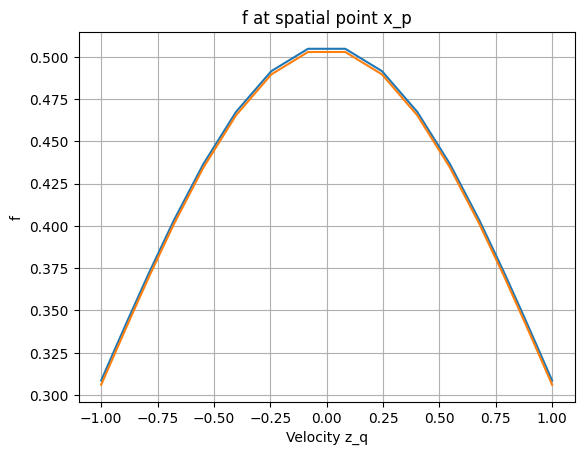

0.04005983857432588


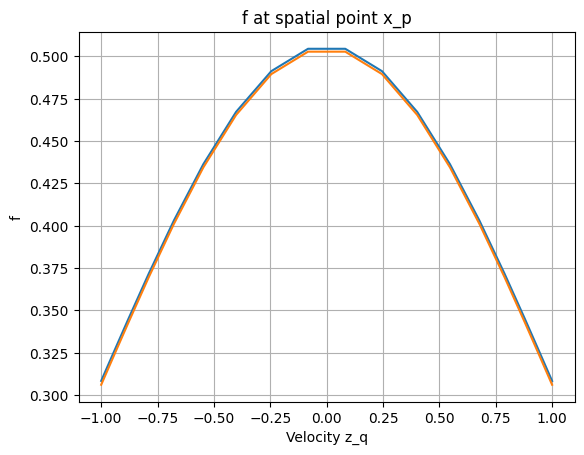

0.03601809586873814


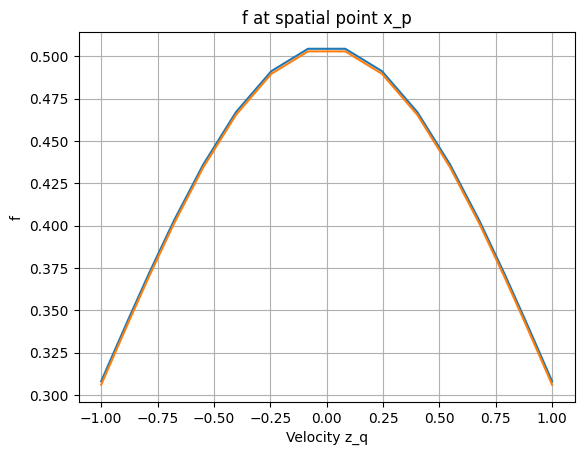

0.032381311940478184


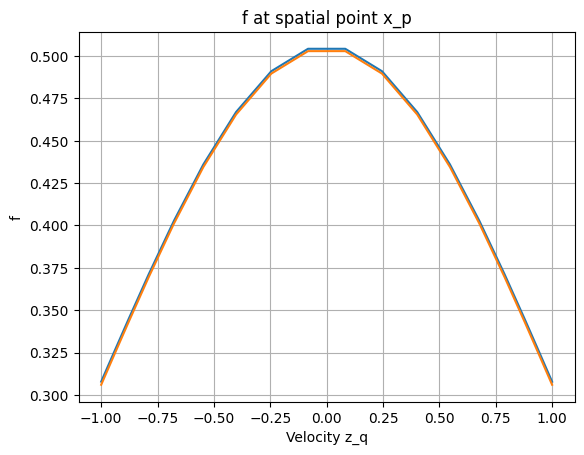

0.02910893597716945


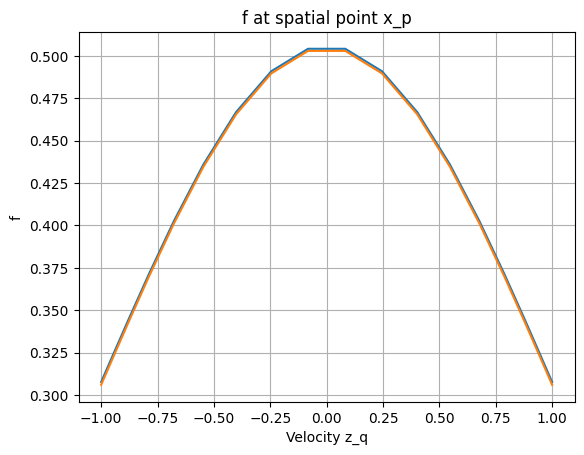

0.026164476979787563


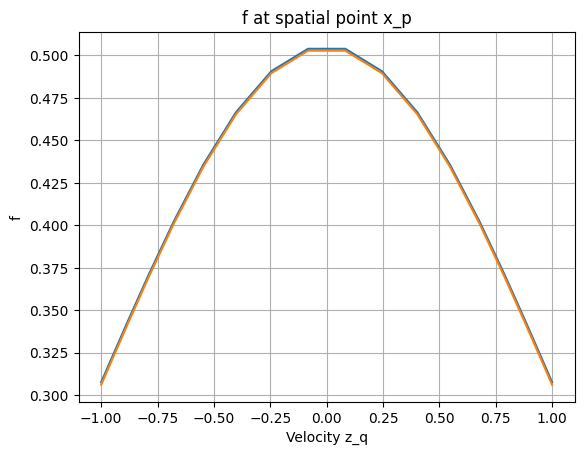

0.02351509757598444


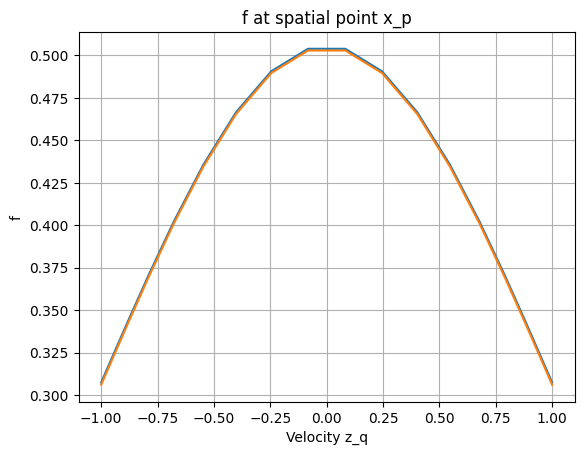

0.021131248468761132


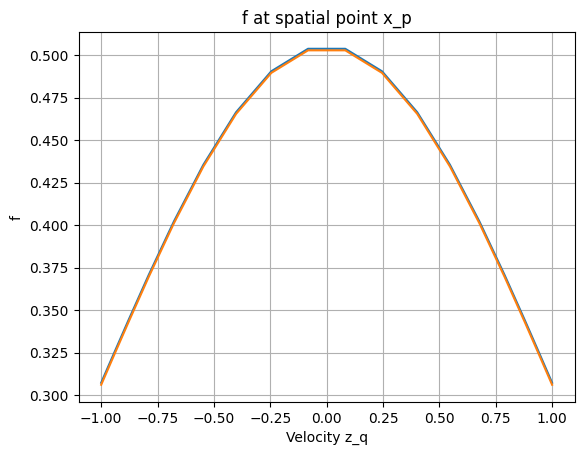

0.01898633946143521


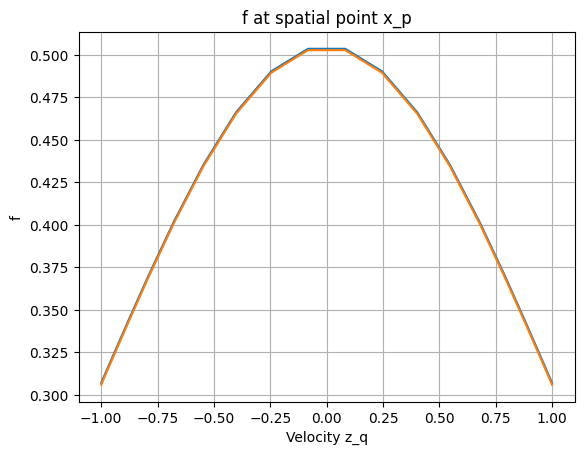

0.017056443400040408


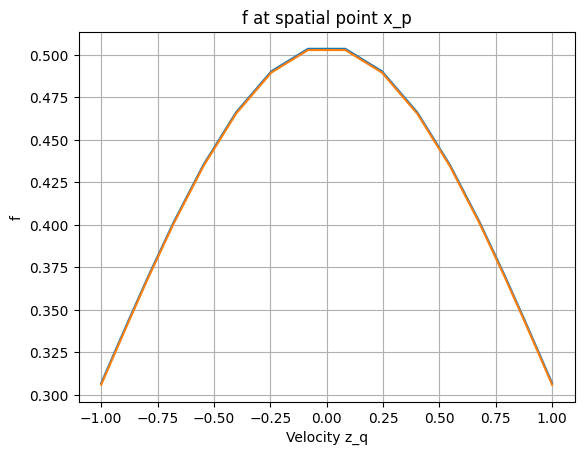

0.01532002974574958


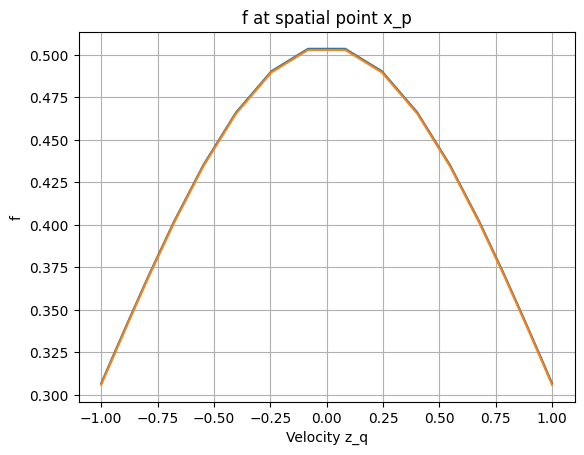

0.013757724815589477


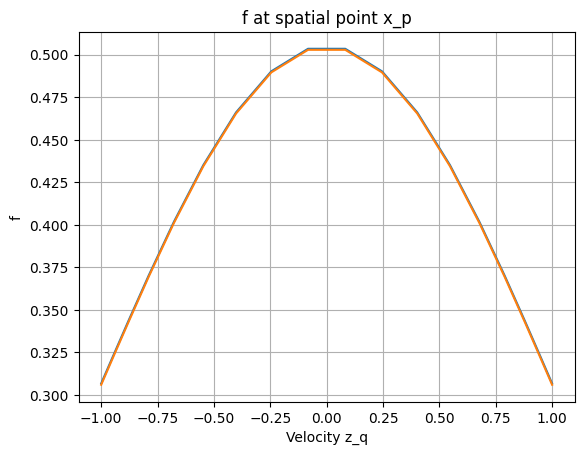

0.01235209602605236


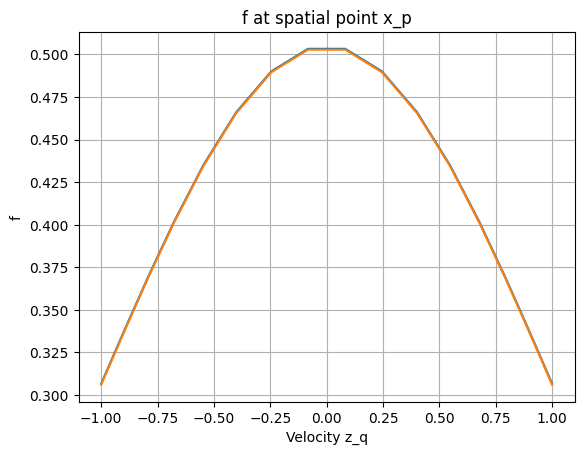

0.011087457743563138


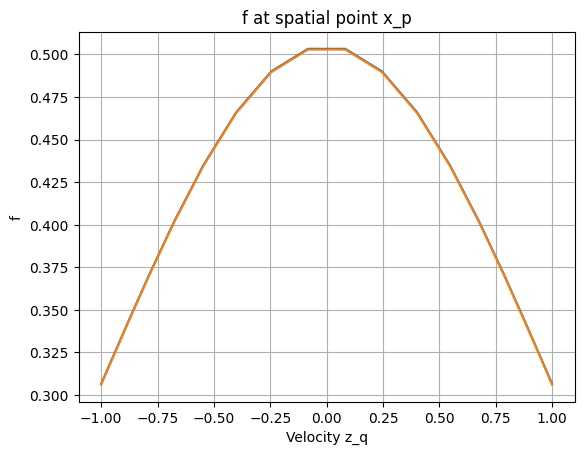

0.009949696583005567


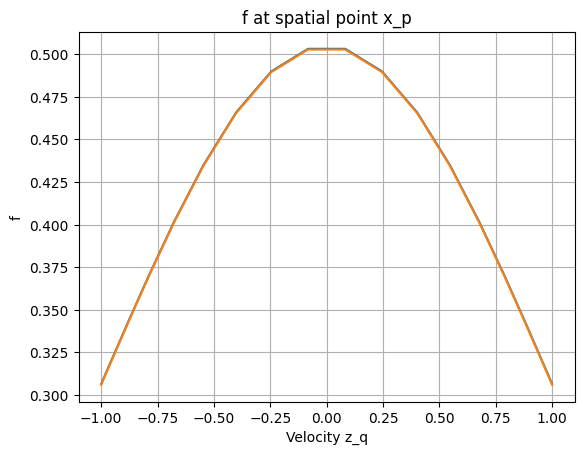

0.008926114214167342


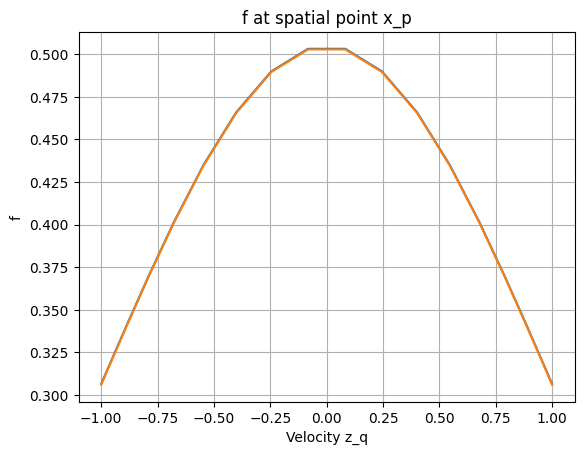

0.008005285929284435


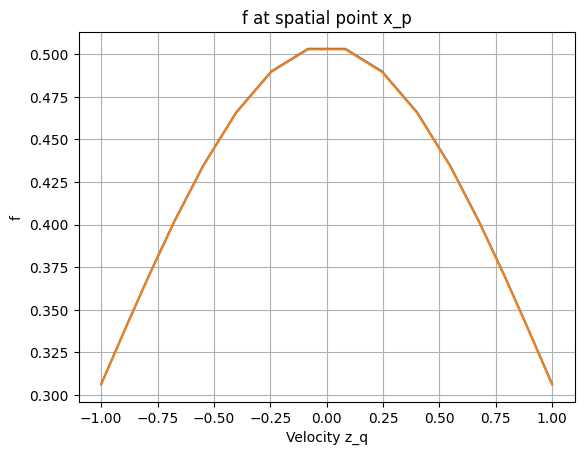

0.007176933402001574


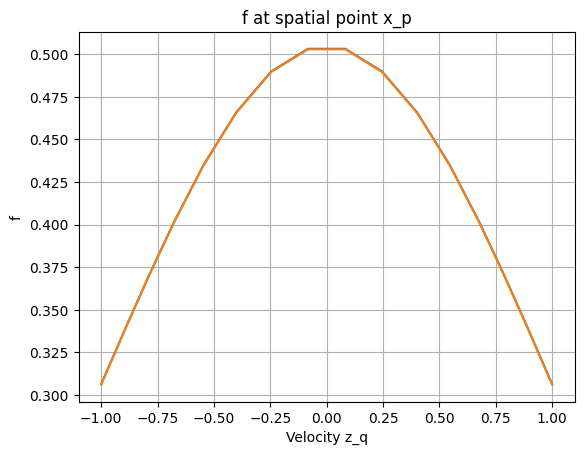

0.006431810224383854


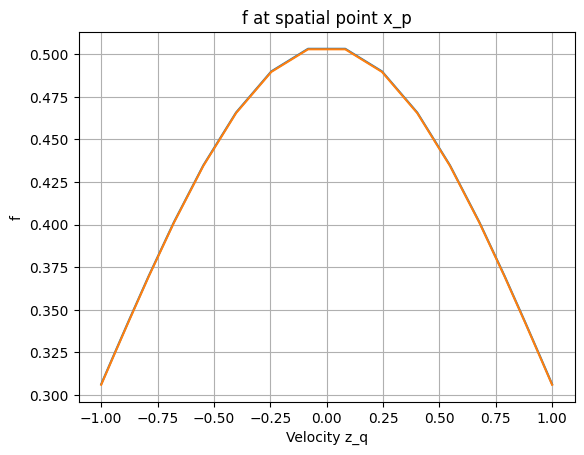

0.0057615989546532026


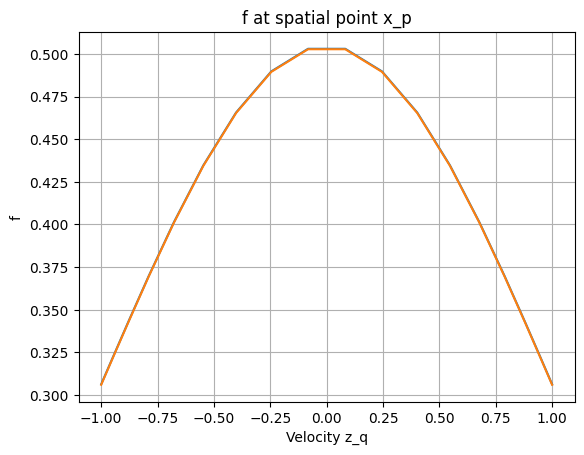

0.005158818533090963


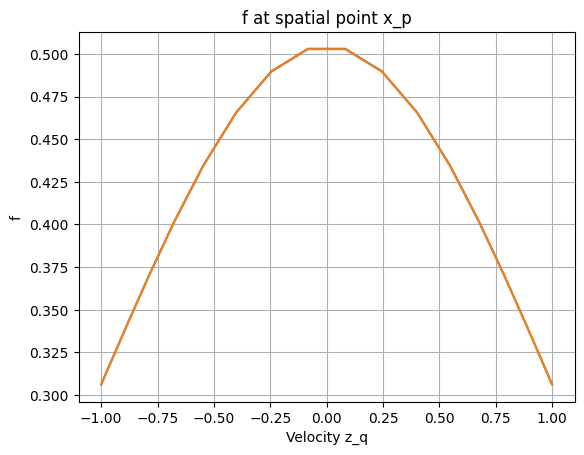

0.0046167410445212345


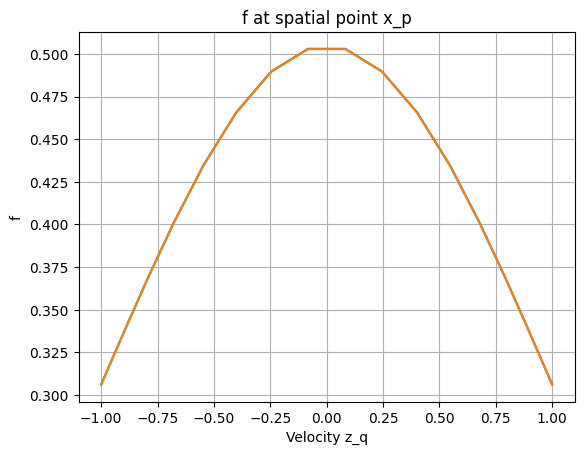

0.004129316906853367


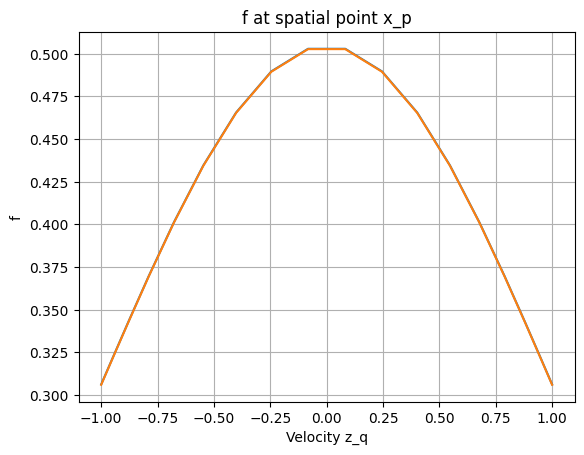

0.0036911076653027143


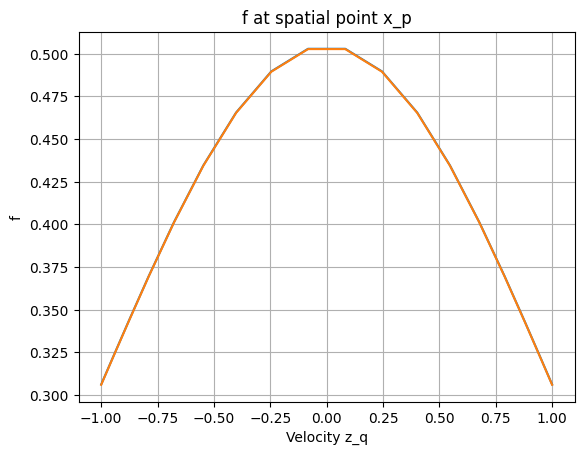

0.003297225653811252


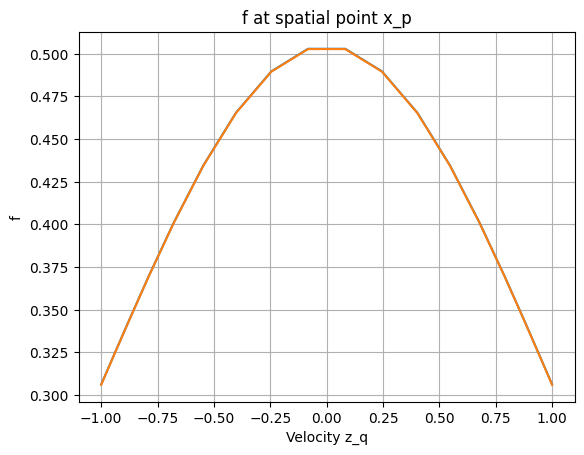

0.002943279869289808


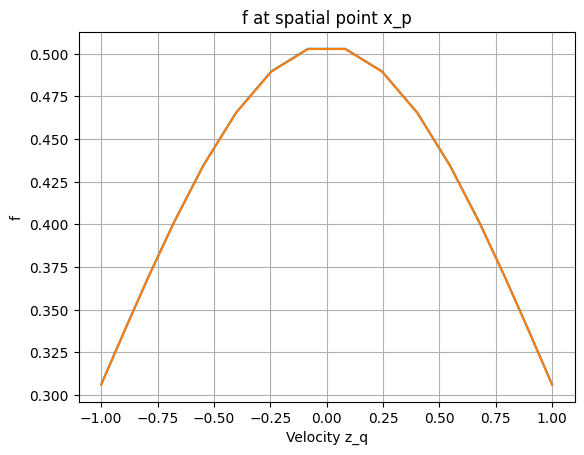

0.0026253274731562804


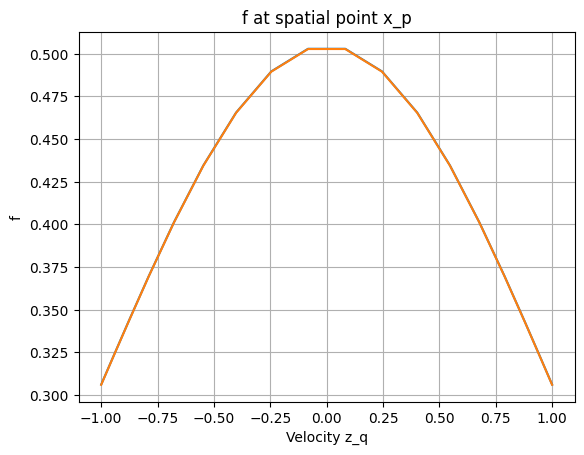

0.0023398304006877614


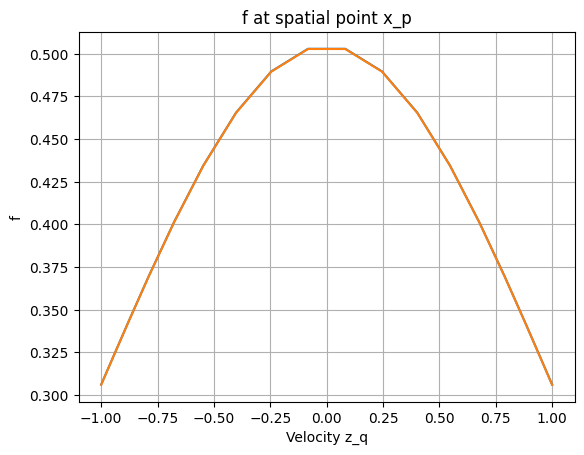

0.0020836166169836646


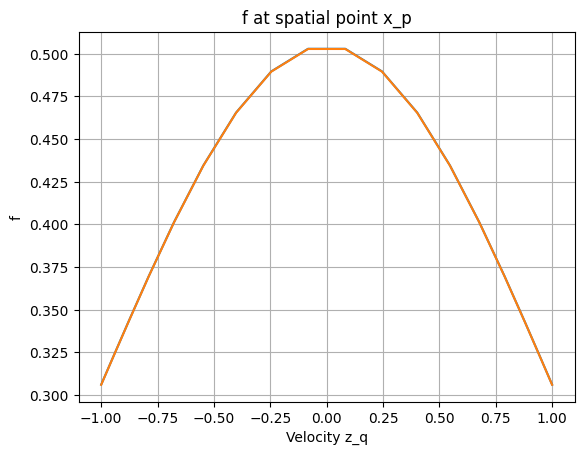

0.001853845613813386


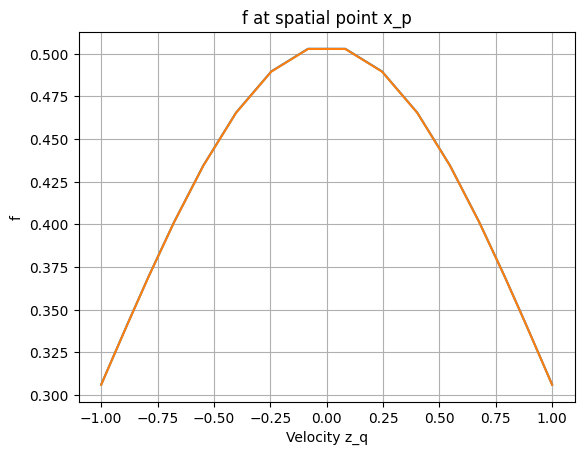

0.0016479777800062073


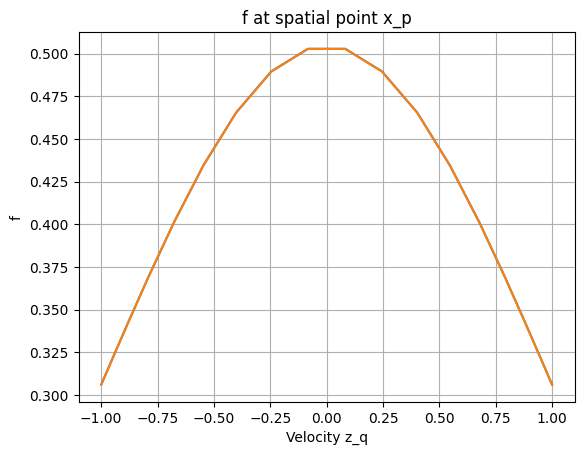

0.001463747309787983


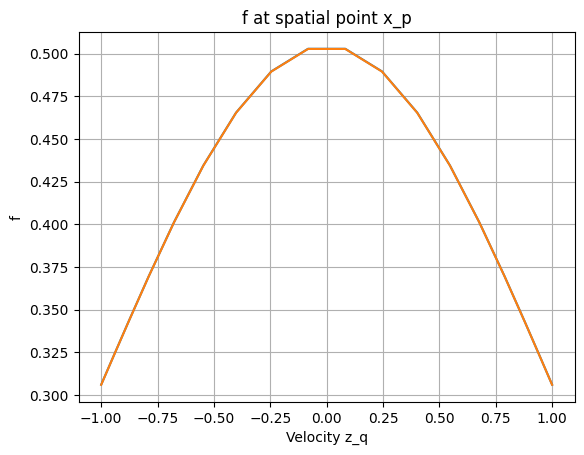

0.001299138322687302


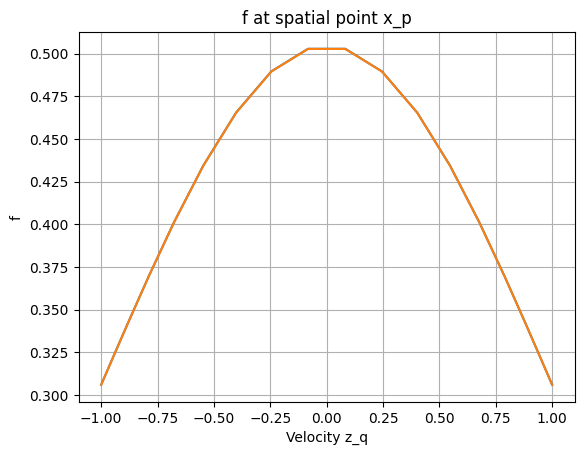

0.0011523638425890344


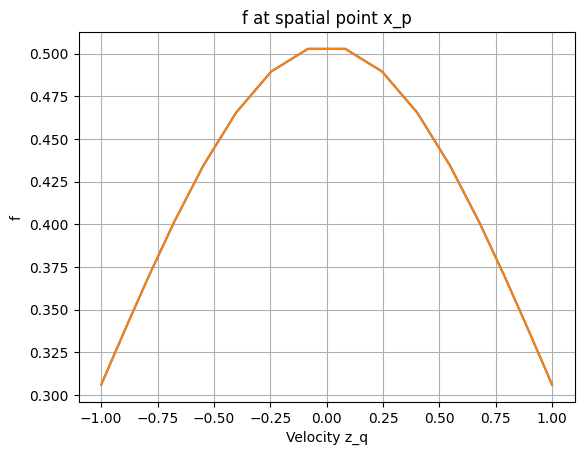

0.0010218471998518699


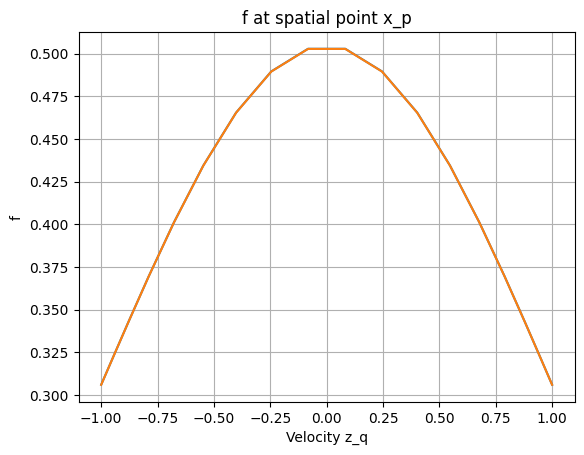

0.0009062052525523927


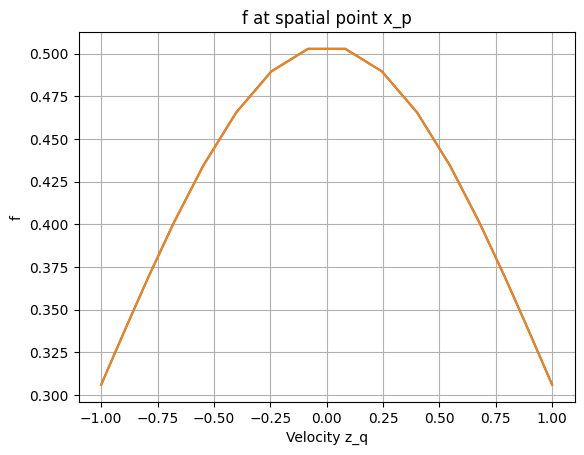

0.0008042325133026441


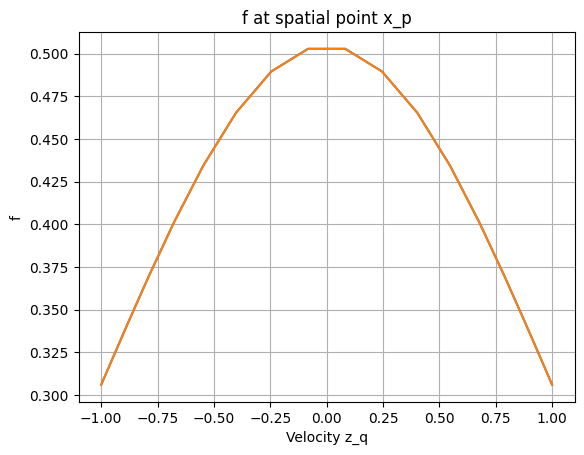

0.0007148847962284821


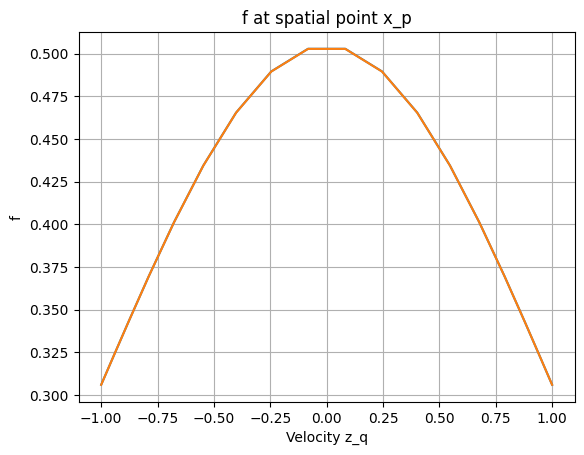

0.0006372603568857199


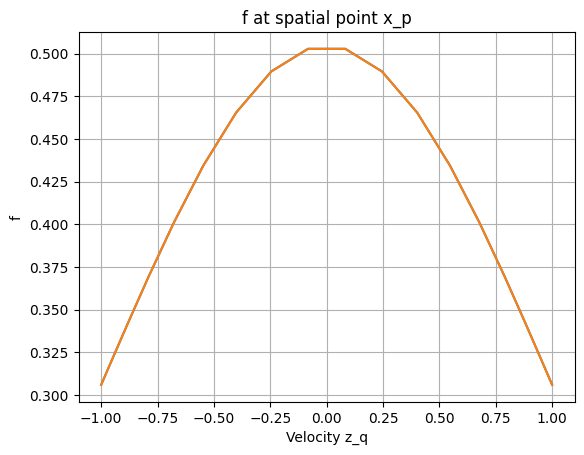

0.0005705758437791524


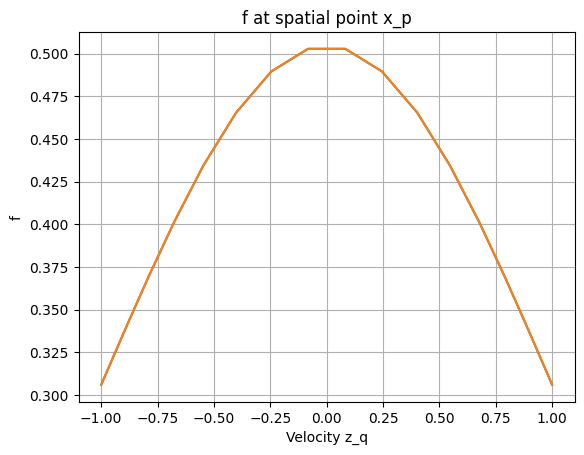

0.0005141341678464723


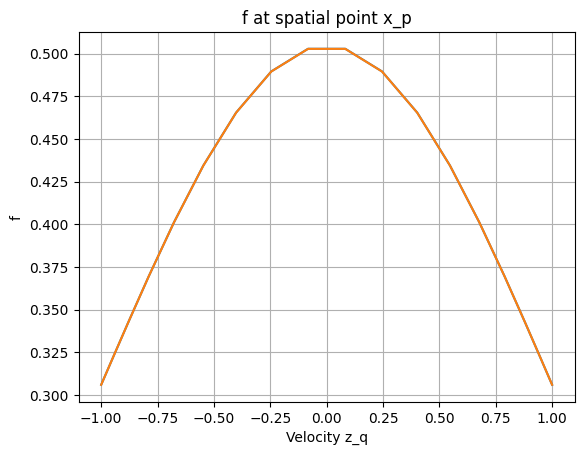

0.0004672824886528535


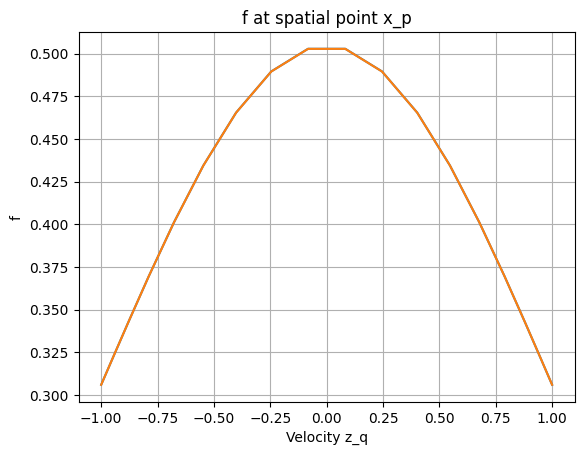

0.000429361989136594


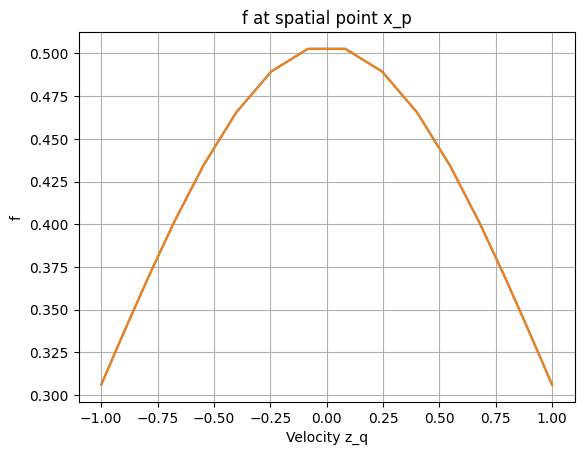

0.0003996571494791615


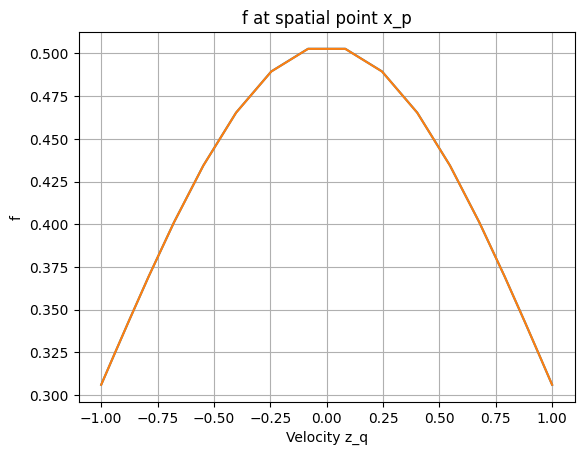

0.0003773584966659768


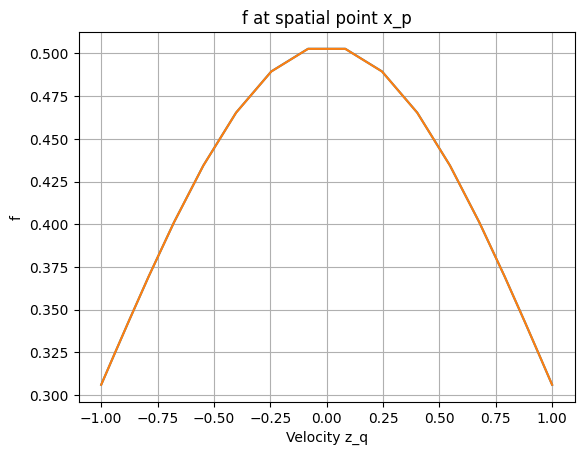

0.000361554042720357


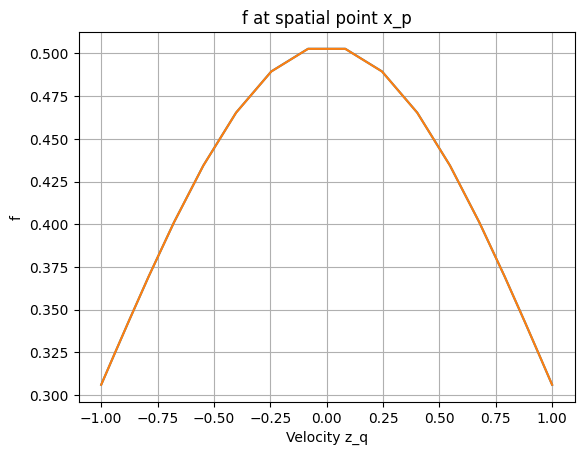

0.0003512565234450856


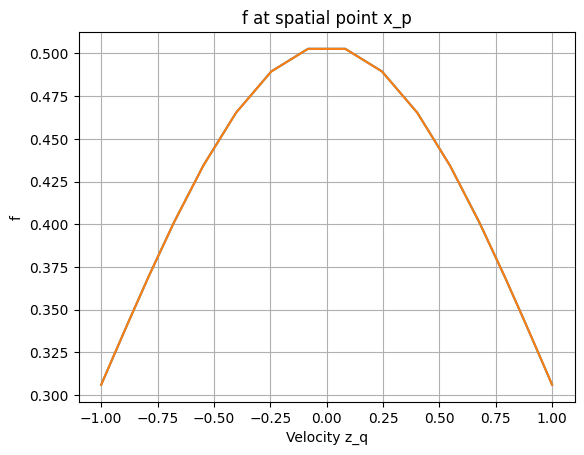

0.0003454587923312757


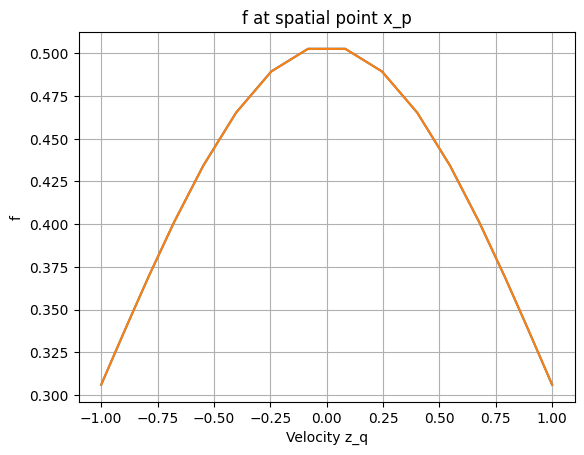

0.0003431980762588183


In [8]:
# # Evaluate initial f at collocation points
# #f_0, f_ini_x, f_ini_z = f_ini(x_p, z_q)  

# # Project f_ini_x onto phi_i(x)
# a = np.linalg.lstsq(A.T, f_ini_x(x_p), rcond=None)[0]

# # Project f_ini_z onto psi_j(z)
# b = np.linalg.lstsq(B.T, f_ini_z(z_q), rcond=None)[0]

# # Form rank-1 tensor product to evaluate C_ini
# C = np.outer(a, b)   # shape (R, R)
# # vec_f0 = f_0.flatten(order='F')
# # coff = np.linalg.pinv(np.kron(B.T,A.T)) @ vec_f0   
# # C = coff.reshape(R,R, order='F')
# # fn = eval_f(C, x_p, z_q)

for n in range(Nt):
    tn = n * dt
    Vel = v(T_x, u_x, x_p, z_q)  # Shape: (N, N)
    # print(Vel.shape)
    Dfnx = eval_D_xf(C, A, B, A_der, B_der, x_p, z_q, T_x, u_x)
    # print(Dfnx.shape)
    vDfnx = np.multiply(Vel, Dfnx)
    # print(vDfnx.shape)
    # print(f'r :{rho_x}')
    # print(f'T {T_x}')
    # print(f'u {u_x}')
    fn = eval_f(C, A, B)
    MW = Maxwellian(rho_x, T_x, x_p, z_q)
    # print(MW.shape)

    # Explicit Euler BGK for f at collocation points    
    fn_new = fn - dt * (vDfnx - (nu / epsilon) * (MW - fn))
    # fn_new = fn_new.astype(float)
    #fn_new_numeric = np.array([[float(val.evalf().as_real_imag()[0]) for val in row] for row in fn_new], dtype=float)
    #fn_new = fn_new_numeric
    
    # Update rho_x
    def G_func(x):
        total = 0
        for i in range(N):
            for j in range(N):
                total += C[i, j] * phi(i, x) * (T_x(x) * int_zpsi_z[j] + np.sqrt(T_x(x)) * u_x(x) * int_psi_z[j])
        return total

    I_1_vals = - np.array([numeric_derivative(G_func, xi) for xi in x_p])
    rho_x_new_vals = rho_x(x_p) + dt * I_1_vals
    #print(rho_x_new_vals)
    rho_x_new = interp1d(x_p, rho_x_new_vals, kind='cubic', fill_value="extrapolate")
    rho_x =rho_x_new

    # Update u_x
    def M_func(x):
        total = 0
        for i in range(N):
            for j in range(N):
                total += C[i, j] * phi(i,x) * (T_x(x) *np.sqrt(T_x(x)) * int_z2psi_z[j] + 2 * T_x(x) * u_x(x) * int_zpsi_z[j] + np.sqrt(T_x(x)) * u_x(x)**2 * int_psi_z[j])
        return total       
    I_2_vals = - np.array([numeric_derivative(M_func, xi) for xi in x_p])
    u_x_new_vals = u_x(x_p) + dt * (I_2_vals - u_x(x_p) * I_1_vals)/ rho_x(x_p)
    u_x_new = interp1d(x_p, u_x_new_vals, kind='cubic', fill_value="extrapolate")
    u_x = u_x_new

    # Update T_x
    def Q_func(x):
        total = 0
        for i in range(N):
            for j in range(N):
                total += C[i, j] * phi(i,x) * (T_x(x)**2 * int_z3psi_z[j] + 3 * T_x(x) * np.sqrt(T_x(x)) * u_x(x) * int_z2psi_z[j] + 3 * T_x(x) * u_x(x)**2 * int_zpsi_z[j] + np.sqrt(T_x(x)) * u_x(x)**3 * int_psi_z[j])
        return total
    #I_3 = - sp.diff(Q,x)/ 2
    I_3_vals = -0.5 * np.array([numeric_derivative(Q_func, xi) for xi in x_p])
    T_x_new_vals = T_x(x_p) - (dt * T_x(x_p) *  I_1_vals )/rho_x(x_p) + 2 * dt/rho_x(x_p) *(I_3_vals + u_x(x_p)**2 * I_1_vals/2 - u_x(x_p) * I_2_vals)
    T_x_new = interp1d(x_p, T_x_new_vals, kind='cubic', fill_value="extrapolate")
    T_x = T_x_new

    C = np.zeros((N,N))
    vec_fn_new = fn_new.flatten(order='F')

    #coff = np.linalg.pinv(np.kron(B.T,A.T)) @ vec_fn_new
    # coff, *_ = np.linalg.lstsq(np.kron(B.T,A.T), vec_fn_new)
    coff= np.linalg.solve(np.kron(B.T,A.T), vec_fn_new)
    
    C = coff.reshape(N,N, order='F')
    err = np.linalg.norm(fn_new - MW)

    # print(MW)
    # print(fn_new)
    
    plt.plot(z_q, fn_new[N//2, :])
    plt.plot(z_q, MW[N//2, :])
    plt.xlabel('Velocity z_q')
    plt.ylabel('f')
    plt.title(f'f at spatial point x_p')
    plt.grid(True)
    plt.show()
    print(err)
    
            

